# PV Tilt

Compare eddy tilt direction with planetary, topographic, and total shallow-water PV-gradient directions.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import seacofs_tilt_tools as tilt

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
#############################################
ELLIPSE_FRAC= 1
USE_PV_CACHE = True
df_eddies, _ = tilt.load_tilt_tables(paths, add_regions=True, grid=grid)
vertical = tilt.load_vert(paths)
df_eddies = tilt.add_pv_gradient_terms(
    df_eddies,
    grid,
    core_mean=True,
    frac=ELLIPSE_FRAC,
    surface_method="esp_gaussian",
    averaging="nonlinear",
    use_max_abs_w=True,
    max_depth_m=1000,
    use_cache=USE_PV_CACHE,
)
#############################################

df_eddies[["Eddy", "Day", "Cyc", "Region", "TiltDis", "TiltDir", "PV_grad_mag", "dtheta_PV_grad"]].head()


,Eddy,Day,Cyc,Region,TiltDis,TiltDir,PV_grad_mag,dtheta_PV_grad
0,1,1462,CE,D1,NaN,NaN,6.798166e-15,NaN
1,1,1463,CE,D1,NaN,NaN,3.915106e-15,NaN
2,1,1464,CE,D1,NaN,NaN,3.132720e-15,NaN
3,1,1465,CE,D1,19.823350,87.507772,8.968861e-15,63.637171
4,1,1466,CE,D1,15.055658,105.302388,1.259266e-14,100.249586


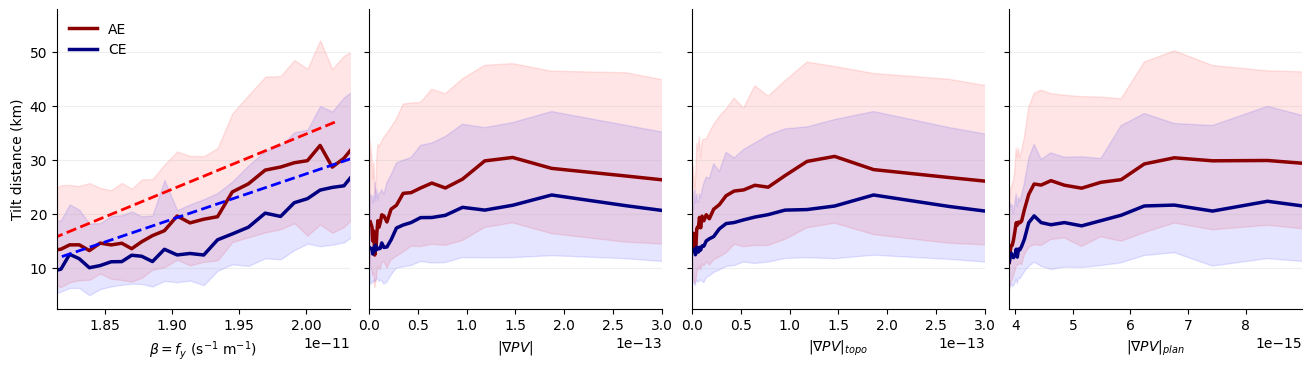

In [2]:
fig, axs = plt.subplots(1, 4, figsize=(13, 3.6), sharey=True, constrained_layout=True)

panels = [
    ("beta", r"$\beta=f_y$ (s$^{-1}$ m$^{-1}$)", None, True),
    ("PV_grad_mag", r"$|\nabla PV|$", (0, 3e-13), False),
    ("PV_grad_topo_mag", r"$|\nabla PV|_{topo}$", (0, 3e-13), False),
    ("PV_grad_plan_mag", r"$|\nabla PV|_{plan}$", None, False),
]

for ax, (col, label, xlim, linfit) in zip(axs, panels):
    tilt.binned_tilt_panel(ax, df_eddies, col, label, xlim=xlim, linfit=linfit)
axs[0].set_ylabel("Tilt distance (km)")
axs[0].legend(frameon=False)
plt.show()


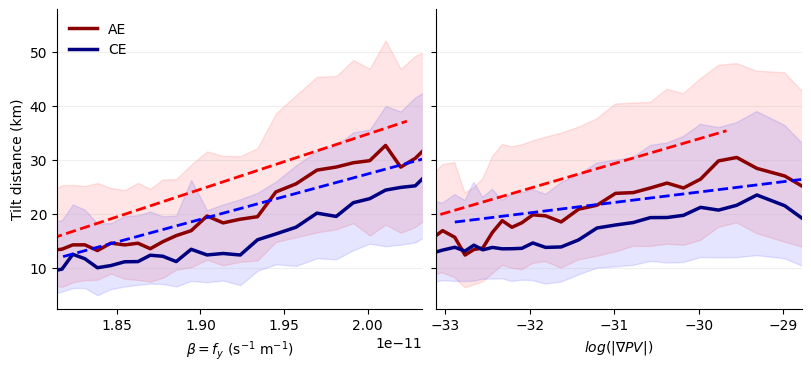

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3.6), sharey=True, constrained_layout=True)

df_eddies['log_PV_grad_mag'] = np.log(df_eddies.PV_grad_mag)

panels = [
    ("beta", r"$\beta=f_y$ (s$^{-1}$ m$^{-1}$)", None, True),
    ("log_PV_grad_mag", r"$log(|\nabla PV|)$", None, True),
]

for ax, (col, label, xlim, linfit) in zip(axs, panels):
    tilt.binned_tilt_panel(ax, df_eddies, col, label, xlim=xlim, linfit=linfit)
axs[0].set_ylabel("Tilt distance (km)")
axs[0].legend(frameon=False)
plt.show()

NameError: name 'bins' is not defined

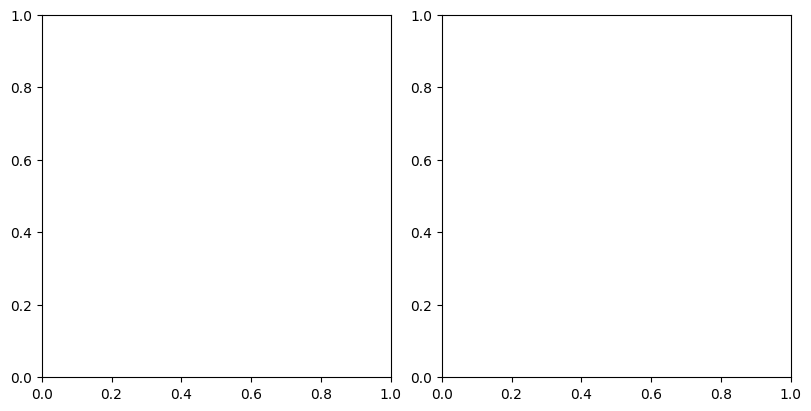

In [4]:
df_plot = df_eddies.copy()
# df_plot = df_plot[df_plot.TiltDis>5]
col_filters = [
    ("Topographic dominated", df_plot.topo_plan_ratio > 0),
    ("Planetary dominated", df_plot.topo_plan_ratio < 0),
]

fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharex=True, constrained_layout=True)
for c, (col_label, mask) in enumerate(col_filters):
        ax = axs[c]
        col = df_plot.loc[mask]
        for cyc, color in [("AE", "darkred"), ("CE", "navy")]:
            # if cyc=='CE':
            vals = col.loc[(col.Cyc == cyc), "dtheta_PV_grad"].dropna()
            ax.hist(vals, bins=bins, histtype="stepfilled", alpha=0.22, color=color)
            ax.hist(vals, bins=bins, histtype="step", linewidth=1.8, color=color, label=cyc if c==0 else None)
        ax.axvline(90, color="0.5", linestyle=":")
        ax.set_xlim(0, 180)
        ax.set_title(col_label)
for ax in axs:
    ax.set_xticks([0, 90, 180])
    ax.set_xticklabels(["Aligned", "Perpendicular", "Opposite"])
axs[0].set_ylabel('Frequency')
axs[0].legend(frameon=False)
plt.show()

In [ ]:
df_plot = df_eddies.copy()
col_filters = [
    ("Topographic dominated", df_plot.topo_plan_ratio > 0),
    ("Planetary dominated", df_plot.topo_plan_ratio < 0),
]

fig, axs = plt.subplots(1, 2, figsize=(8, 4), sharex=True, constrained_layout=True)
for c, (col_label, mask) in enumerate(col_filters):
        ax = axs[c]
        col = df_plot.loc[mask]
        for cyc, color in [("AE", "darkred"), ("CE", "navy")]:
            # if cyc=='CE':
            vals = col.loc[(col.Cyc == cyc), "dtheta_PV_grad"].dropna()
            ax.hist(vals, bins=bins, histtype="stepfilled", alpha=0.22, color=color)
            ax.hist(vals, bins=bins, histtype="step", linewidth=1.8, color=color, label=cyc if c==0 else None)
        ax.axvline(90, color="0.5", linestyle=":")
        ax.set_xlim(0, 180)
        ax.set_title(col_label)
for ax in axs:
    ax.set_xticks([0, 90, 180])
    ax.set_xticklabels(["Aligned", "Perpendicular", "Opposite"])
axs[0].set_ylabel('Frequency')
axs[0].legend(frameon=False)
plt.show()

## PV-gradient regional rose plot

The same regional rose layout can be used with PV-gradient magnitude and direction.


In [ ]:
df_eddies['log_PV_grad_mag'].hist()

In [ ]:
pv_mag_bins = [-np.inf, -34, -33, -32, -31, -30, -29, -28, -27, np.inf]
df_eddies['log_PV_grad_mag'] = np.log(df_eddies['PV_grad_mag'])
fig, rose = tilt.rose_plot(
    df_eddies.dropna(subset=["log_PV_grad_mag", "PV_grad_theta"]),
    grid,
    mag="log_PV_grad_mag",
    theta="PV_grad_theta",
    mag_bins=pv_mag_bins,
    frac=3,
    direction_offset=0,
    shelf_offset=80,
    legend_title=r"log$(|\nabla PV|)$",
    rtick_flag=False,
    cmaps = ['Oranges', 'Purples']
)

#### PV dominance

In [ ]:
fig, axs = tilt.plot_pv_dominance(
    df_eddies.dropna(subset=["PV_grad_topo_mag", "PV_grad_plan_mag"]),
    grid,
    clabel=r'Fraction of eddy-days with $|\beta_{plan}| < |\beta_{topo}|$'
)
# region_mask_grid, bin_grid = tilt.make_region_grids(grid)
# for ax in axs:
#     ax.contour(grid.X_grid, grid.Y_grid, region_mask_grid.astype(float), levels=[0.5],
#                colors="magenta", linewidths=2, linestyles='-')

In [ ]:
df_AE = df_eddies[df_eddies.Cyc == 'AE']
df_CE = df_eddies[df_eddies.Cyc == 'CE']

AE_PV = df_AE.PV_grad_mag.mean()
CE_PV = df_CE.PV_grad_mag.mean()

AE_topo = df_AE.PV_grad_topo_mag.mean()
CE_topo = df_CE.PV_grad_topo_mag.mean()

AE_plan = df_AE.PV_grad_plan_mag.mean()
CE_plan = df_CE.PV_grad_plan_mag.mean()

print('Mean PV-gradient magnitudes')
print('-' * 35)
print(f'Total:        AE = {AE_PV:.3e}    CE = {CE_PV:.3e}    (CE/AE = {CE_PV/AE_PV:.2f})')
print(f'Topographic:  AE = {AE_topo:.3e}    CE = {CE_topo:.3e}    (CE/AE = {CE_topo/AE_topo:.2f})')
print(f'Planetary:    AE = {AE_plan:.3e}    CE = {CE_plan:.3e}    (CE/AE = {CE_plan/AE_plan:.2f})')
print()
print('Topographic / Planetary ratio')
print('-' * 35)
print(f'AE = {AE_topo/AE_plan:.2f}')
print(f'CE = {CE_topo/CE_plan:.2f}')

In [ ]:
# fig, axs = tilt.tilt_t(df_eddies.copy(), add_field='PV_grad_mag', field_label='PV grad.')
fig, axs = tilt.tilt_t(df_eddies.copy(), grid, add_field='PV_grad_mag', field_label='PV grad.', nlargest=20, figsize=(10,30))

In [ ]:
df_eddies['beta_abs'] = df_eddies.beta.abs()
fig, axs = tilt.tilt_t(df_eddies.copy(), grid, add_field='beta_abs', field_label='beta_abs')

In [ ]:
# fig, axs = tilt_t(df_eddies.copy(), add_field='f', field_label='f')

In [ ]:
df_eddies.columns